<a href="https://colab.research.google.com/github/fralfaro/ICS40125/blob/main/docs/labs/lab_08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# ICS40125 - Laboratorio N°08

**Objetivo**: Aplicar técnicas de **machine learning no supervisado** para explorar, procesar y analizar conjuntos de datos con variables numéricas y categóricas.

> **Nota**: Puede ayudarse de algún asistente virtual como **ChatGPT, Gemini** u otros, así como del autocompletado de **Google Colab**, para avanzar en este laboratorio debido a su extensión.


## Clustering


<img src="https://www.svgrepo.com/show/253022/car.svg" width = "300" align="center"/>



El conjunto de datos **`vehiculos_procesado_con_grupos.csv`** recopila información sobre diversas características relevantes de distintos vehículos. El propósito de este ejercicio es **clasificar los vehículos en diferentes categorías**, utilizando como base las variables descritas en la tabla de atributos.

El análisis presenta un desafío adicional debido a la **naturaleza mixta de los datos**: se incluyen tanto variables **numéricas** (ej. dimensiones, consumo, emisiones) como **categóricas** (ej. tipo de tracción, tipo de combustible), lo que requiere aplicar técnicas de preprocesamiento adecuadas antes de entrenar los modelos.

Como primer paso, procederemos a **cargar y explorar el conjunto de datos**, con el fin de familiarizarnos con su estructura y las características que servirán como base para la posterior clasificación.




**Descripción de los Datos:**

| **Nombre de la Columna**   | **Descripción**                                                                                                                                   |
|----------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------|
| **year**                   | El año en que el vehículo fue fabricado.                                                                                                          |
| **desplazamiento**          | La capacidad volumétrica del motor en litros. Indica la cantidad de aire y combustible que puede desplazar el motor durante una revolución.       |
| **cilindros**               | El número de cilindros que tiene el motor. Los cilindros son las cámaras donde ocurre la combustión interna en los motores de los vehículos.       |
| **co2**                     | Emisiones de dióxido de carbono del vehículo, medido en gramos por kilómetro. Es una medida de las emisiones de gases de efecto invernadero.       |
| **clase_tipo**              | La clase o tipo de vehículo, como vehículos especiales, deportivos, etc.                                                                         |
| **traccion_tipo**           | Tipo de tracción del vehículo, ya sea tracción en dos ruedas, en cuatro ruedas o en todas las ruedas.                                             |
| **transmision_tipo**        | Tipo de transmisión del vehículo, como automática, manual, entre otros.                                                                          |
| **combustible_tipo**        | Tipo de combustible que utiliza el vehículo, como gasolina, diésel, eléctrico, híbrido, etc.                                                     |
| **tamano_motor_tipo**       | Clasificación del tamaño del motor (por ejemplo, pequeño, mediano o grande), que generalmente se basa en la capacidad de desplazamiento.           |
| **consumo_tipo**            | Clasificación del nivel de consumo de combustible del vehículo, indicando si es alto, bajo, o muy alto.                                           |
| **co2_tipo**                | Clasificación de las emisiones de CO2 del vehículo, indicando si es alto, bajo, o muy alto.                                                       |
| **consumo_litros_milla**    | El consumo de combustible del vehículo, medido en litros por milla. Indica la eficiencia del vehículo en términos de consumo de combustible.        |



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.dummy import DummyClassifier
from sklearn.cluster import KMeans


%matplotlib inline

sns.set_palette("deep", desat=.6)
sns.set(rc={'figure.figsize':(11.7,8.27)})

In [2]:
# cargar datos
df = pd.read_csv("https://raw.githubusercontent.com/fralfaro/ICS40125/main/docs/labs/data/vehiculos_procesado_con_grupos.csv", sep=",")\
       .drop(
            ["fabricante",
             "modelo",
             "transmision",
             "traccion",
             "clase",
             "combustible",
             "consumo"],

          axis=1)

df.head()

,year,desplazamiento,cilindros,co2,clase_tipo,traccion_tipo,transmision_tipo,combustible_tipo,tamano_motor_tipo,consumo_tipo,co2_tipo,consumo_litros_milla
0,1984,2.5,4.0,522.764706,Vehículos Especiales,dos,Automatica,Normal,pequeño,alto,alto,0.222671
1,1984,4.2,6.0,683.615385,Vehículos Especiales,dos,Automatica,Normal,grande,muy alto,muy alto,0.291185
2,1985,2.5,4.0,555.437500,Vehículos Especiales,dos,Automatica,Normal,pequeño,alto,alto,0.236588
3,1985,4.2,6.0,683.615385,Vehículos Especiales,dos,Automatica,Normal,grande,muy alto,muy alto,0.291185
4,1987,3.8,6.0,555.437500,Coches Medianos,dos,Automatica,Premium,grande,alto,alto,0.236588


En este caso, no solo se tienen datos numéricos, sino que también categóricos. Además, tenemos problemas de datos **vacíos (Nan)**. Así que para resolver este problema, seguiremos varios pasos:

### 1.- Normalizar datos

- Cree un conjunto de datos con las variables numéricas, además, para cada dato vacía, rellene con el promedio asociado a esa columna. Finalmente, normalize los datos mediante el procesamiento **MinMaxScaler** de **sklearn**.
- Cree un conjunto de datos con las variables categóricas , además, transforme de variables categoricas a numericas ocupando el comando **get_dummies** de pandas ([referencia](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.get_dummies.html)). Explique a grande rasgo como se realiza la codificación de variables numéricas a categóricas.

- Junte ambos dataset en uno, llamado **df_procesado**.

In [3]:
# FIXME

# 1. Separación de tipos de columnas e imputación/escalamiento numérico
columnas_num = df.select_dtypes(include=[np.number]).columns.tolist()
df_num = df[columnas_num].copy()

# Rellenar valores vacíos (NaN) con el promedio de cada columna
df_num = df_num.fillna(df_num.mean())

# Escalamiento con MinMaxScaler
scaler = MinMaxScaler()
df_num_scaled = pd.DataFrame(scaler.fit_transform(df_num), columns=columnas_num)

# 2. Tratamiento de variables categóricas mediante codificación One-Hot
columnas_cat = df.select_dtypes(exclude=[np.number]).columns.tolist()
# Convertimos a dummies usando get_dummies
df_cat_encoded = pd.get_dummies(df[columnas_cat], drop_first=False)

# 3. Concatenar ambos subconjuntos en el dataframe unificado solicitado
df_procesado = pd.concat([df_num_scaled, df_cat_encoded], axis=1)

print("--- Estructura final de df_procesado ---")
print(f"Dimensiones: {df_procesado.shape}")
print(df_procesado.head(2))

print("\n--- EXPLICACIÓN DE LA CODIFICACIÓN (One-Hot / get_dummies) ---")
print("La codificación a variables de tipo dummy consiste en transformar cada valor único de ")
print("una columna categórica en una columna individual independiente con formato booleano (0 o 1). ")
print("De este modo, si la variable 'traccion_tipo' contiene 'dos' y 'cuatro', pasará a convertirse ")
print("en las variables binarias 'traccion_tipo_dos' y 'traccion_tipo_cuatro'. Esto evita asignaciones ")
print("arbitrarias de orden numérico (como 1, 2, 3) que confundan a algoritmos basados en distancias.")

--- Estructura final de df_procesado ---
Dimensiones: (36791, 36)
   year  desplazamiento  cilindros       co2  consumo_litros_milla  \
0   0.0        0.243590   0.142857  0.398014              0.331027   
1   0.0        0.461538   0.285714  0.527672              0.475113   

   clase_tipo_Camionetas  clase_tipo_Coche Familiar  \
0                  False                      False   
1                  False                      False   

   clase_tipo_Coches Grandes  clase_tipo_Coches Medianos  \
0                      False                       False   
1                      False                       False   

   clase_tipo_Coches pequeños  ...  consumo_tipo_alto  consumo_tipo_bajo  \
0                       False  ...               True              False   
1                       False  ...              False              False   

   consumo_tipo_moderado  consumo_tipo_muy alto  consumo_tipo_muy bajo  \
0                  False                  False                  False   

### 2.- Realizar ajuste mediante kmeans

Una vez depurado el conjunto de datos, es momento de aplicar el algoritmo de **kmeans**.

1. Ajuste el modelo de **kmeans** sobre el conjunto de datos, con un total de **8 clusters**.
2. Asociar a cada individuo el correspondiente cluster y calcular valor de los centroides de cada cluster.
3. Realizar un resumen de las principales cualidades de cada cluster. Para  esto debe calcular (para cluster) las siguientes medidas de resumen:
    * Valor promedio de las variables numérica
    * Moda para las variables numericas

In [4]:
# FIXME

# 1. Instanciar y ajustar el modelo K-Means con k=8
kmeans_8 = KMeans(n_clusters=8, random_state=42, n_init=10)
df['cluster_id'] = kmeans_8.fit_predict(df_procesado)

print("--- Distribución de vehículos por clúster ---")
print(df['cluster_id'].value_counts())

# 2. Obtener Centroides numéricos en el espacio procesado
centroides_procesados = kmeans_8.cluster_centers_

# 3. Resumen de cualidades sobre el dataset original combinando promedios y modas
print("\n--- PERFIL DE CUALIDADES DE LOS 8 CLÚSTERES ---")

for i in range(8):
    df_sub = df[df['cluster_id'] == i]
    print(f"\n================ Clúster {i} (Tamaño: {len(df_sub)}) ================")

    # Promedio de variables numéricas
    print("-> Promedios Numéricos:")
    print(df_sub[columnas_num].mean().round(2).to_dict())

    # Moda para las variables categóricas (y estructurales)
    print("-> Modas Categóricas Dominantes:")
    modas = df_sub[columnas_cat].mode().iloc[0].to_dict()
    for cat_col, mod_val in modas.items():
        print(f"   * {cat_col}: {mod_val}")

--- Distribución de vehículos por clúster ---
cluster_id
1    7384
2    6057
7    4856
3    4674
4    4108
5    3987
6    3036
0    2689
Name: count, dtype: int64

--- PERFIL DE CUALIDADES DE LOS 8 CLÚSTERES ---

================ Clúster 0 (Tamaño: 2689) ================
-> Promedios Numéricos:
{'year': 1998.53, 'desplazamiento': 2.35, 'cilindros': 4.43, 'co2': 406.88, 'consumo_litros_milla': 0.17}
-> Modas Categóricas Dominantes:
   * clase_tipo: Coches pequeños
   * traccion_tipo: dos
   * transmision_tipo: Manual
   * combustible_tipo: Normal
   * tamano_motor_tipo: pequeño
   * consumo_tipo: bajo
   * co2_tipo: bajo

================ Clúster 1 (Tamaño: 7384) ================
-> Promedios Numéricos:
{'year': 2003.36, 'desplazamiento': 1.92, 'cilindros': 4.04, 'co2': 327.75, 'consumo_litros_milla': 0.14}
-> Modas Categóricas Dominantes:
   * clase_tipo: Coches pequeños
   * traccion_tipo: dos
   * transmision_tipo: Automatica
   * combustible_tipo: Normal
   * tamano_motor_tipo: muy 

### 3.- Elegir Número de cluster

Estime mediante la **regla del codo**, el número de cluster apropiados para el caso.
Para efectos prácticos, eliga la siguiente secuencia como número de clusters a comparar:

$$[5, 10, 20, 30, 50, 75, 100, 200, 300]$$

Una vez realizado el gráfico, saque sus propias conclusiones del caso.

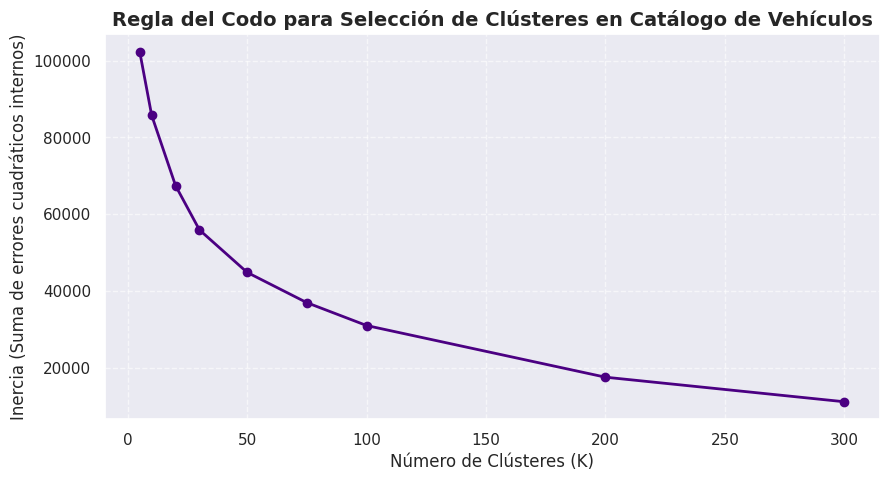


--- CONCLUSIONES DE LA REGLA DEL CODO ---
Al observar el gráfico de inercia para este dataset de alta dimensionalidad mixta, 
vemos que el codo no es abrupto sino una transición gradual. Sin embargo, se aprecia que 
entre K=20 y K=50 el decrecimiento drástico de la inercia comienza a estabilizarse (aplanarse).
Elegir un K entre 20 o 30 representa un excelente equilibrio práctico para agrupar este mercado 
sin sobre-segmentar los tipos de automóviles.


In [5]:
# FIXME

secuencia_k = [5, 10, 20, 30, 50, 75, 100, 200, 300]
inercias = []

for k in secuencia_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=5, max_iter=200)
    km.fit(df_procesado)
    inercias.append(km.inertia_)

# Graficar curva del codo
plt.figure(figsize=(10, 5))
plt.plot(secuencia_k, inercias, marker='o', linestyle='-', color='indigo', linewidth=2)
plt.title('Regla del Codo para Selección de Clústeres en Catálogo de Vehículos', fontsize=14, fontweight='bold')
plt.xlabel('Número de Clústeres (K)', fontsize=12)
plt.ylabel('Inercia (Suma de errores cuadráticos internos)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("\n--- CONCLUSIONES DE LA REGLA DEL CODO ---")
print("Al observar el gráfico de inercia para este dataset de alta dimensionalidad mixta, ")
print("vemos que el codo no es abrupto sino una transición gradual. Sin embargo, se aprecia que ")
print("entre K=20 y K=50 el decrecimiento drástico de la inercia comienza a estabilizarse (aplanarse).")
print("Elegir un K entre 20 o 30 representa un excelente equilibrio práctico para agrupar este mercado ")
print("sin sobre-segmentar los tipos de automóviles.")

Al observar el gráfico resultante, se pueden obtener conclusiones sobre el número apropiado de clusters. La regla del codo sugiere elegir el número de clusters donde la reducción en la inercia se estabiliza significativamente. En otras palabras, se busca el punto en el gráfico donde la curva de inercia comienza a aplanarse o forma un codo.

## Reducción de Dimensionalidad

<img src="https://1000logos.net/wp-content/uploads/2020/11/Wine-Logo-old.png" width = "300" align="center"/>


Para este ejercicio utilizaremos el **Wine Dataset**, un conjunto de datos clásico disponible en la librería **scikit-learn** y en el repositorio de la **UCI Machine Learning**.
Este dataset contiene información de **178 muestras de vino** provenientes de la región italiana de *Piamonte*. Cada vino pertenece a una de **tres variedades de uva** (*clases*), que actúan como etiquetas para el análisis supervisado, pero aquí se usarán solo como referencia en la visualización.

Cada muestra está descrita por **13 variables químicas** obtenidas de un análisis de laboratorio, entre ellas:

* **Alcohol**: porcentaje de alcohol en el vino.
* **Malic acid**: concentración de ácido málico.
* **Ash**: contenido de ceniza.
* **Alcalinity of ash**: alcalinidad de la ceniza.
* **Magnesium**: cantidad de magnesio (mg/L).
* **Total phenols**: concentración total de fenoles.
* **Flavanoids**: tipo de fenoles con propiedades antioxidantes.
* **Nonflavanoid phenols**: fenoles que no son flavonoides.
* **Proanthocyanins**: compuestos relacionados con el color y el sabor.
* **Color intensity**: intensidad del color del vino.
* **Hue**: matiz del color.
* **OD280/OD315 of diluted wines**: relación de absorbancia que mide la calidad del vino.
* **Proline**: concentración de prolina (un aminoácido).

Estas características permiten representar cada vino como un punto en un espacio de **13 dimensiones**.

El objetivo del análisis con este dataset es **reducir la dimensionalidad** para visualizar y explorar patrones en los datos. Para ello aplicaremos:

* **PCA (Principal Component Analysis):** identificar las combinaciones lineales de variables que explican la mayor varianza en el conjunto.
* **t-SNE (t-distributed Stochastic Neighbor Embedding):** mapear las muestras a 2D o 3D, preservando relaciones de vecindad y estructuras no lineales.

La comparación entre ambas técnicas permitirá observar cómo las tres clases de vinos se diferencian en el espacio reducido y discutir la utilidad de la reducción de dimensionalidad en datos con mayor número de variables que en el caso del dataset *Wine*.



In [ ]:
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

In [ ]:
# cargar dataset
dataset = load_wine()

# nombres de las variables
features = dataset.feature_names
target = 'wine_class'

# construir DataFrame
wine = pd.DataFrame(dataset.data, columns=features)
wine[target] = dataset.target

# ver primeras filas
wine.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,wine_class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0




### 1. **Análisis detallado con PCA**

* Calcular la **varianza explicada** por cada componente principal y representar el gráfico de varianza acumulada, identificando cuántos componentes son necesarios para capturar al menos el **90–95% de la información**.
* Construir tablas y gráficos que muestren cómo las observaciones (vinos) se proyectan en las primeras componentes principales.
* Analizar los **loadings** (coeficientes de cada variable en los componentes) e interpretar qué características químicas del vino (alcohol, fenoles, color, etc.) tienen mayor influencia en las nuevas dimensiones.
* Visualizar los datos reducidos a 2D o 3D e interpretar si las **tres variedades de vino** se separan de forma clara en el espacio proyectado.



In [7]:
# FIXME
from sklearn.preprocessing import StandardScaler

# Separar variables predictoras químicas
X_wine = wine[features]
y_wine = wine[target]

# PASO CRÍTICO EN PCA: Estandarizar con media 0 y varianza 1
X_wine_scaled = StandardScaler().fit_transform(X_wine)

# Ajustar PCA con todos los componentes posibles (13)
pca_completo = PCA(random_state=42)
X_pca = pca_completo.fit_transform(X_wine_scaled)

var_explicada = pca_completo.explained_variance_ratio_
var_acumulada = np.cumsum(var_explicada)

# 1. Gráfico de varianza acumulada
plt.figure(figsize=(8, 4))
plt.bar(range(1, 14), var_explicada, alpha=0.6, align='center', label='Varianza Individual', color='g')
plt.step(range(1, 14), var_acumulada, where='mid', label='Varianza Acumulada', color='red', linewidth=2)
plt.axhline(y=0.90, color='blue', linestyle='--', label='90% Varianza')
plt.title('Varianza Explicada Acumulada por Componente Principal (PCA)')
plt.xlabel('Componentes Principales')
plt.ylabel('Proporción de Varianza Capturada')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

# Encontrar cuántos componentes cubren el 90%
n_comp_90 = np.argmax(var_acumulada >= 0.90) + 1
print(f"-> Para capturar al menos el 90% de la información se requieren: {n_comp_90} componentes.")

# 2. Análisis de Loadings (Pesos) para los dos primeros componentes
df_loadings = pd.DataFrame(pca_completo.components_[:2].T, columns=['PC1', 'PC2'], index=features)
print("\n--- Loadings de las Características en PC1 y PC2 ---")
print(df_loadings.round(3))

# 3. Visualizar datos en espacio reducido 2D (PC1 vs PC2)
plt.figure(figsize=(9, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_wine, palette='Set1', s=80, edgecolor='k')
plt.title('Proyección Lineal de Vinos en el Espacio de Componentes Principales (PCA)', fontsize=13)
plt.xlabel(f'PC1 ({var_explicada[0]:.2%} var)')
plt.ylabel(f'PC2 ({var_explicada[1]:.2%} var)')
plt.legend(title='Variedad de Uva (Clase)')
plt.grid(True, alpha=0.3)
plt.show()

NameError: name 'wine' is not defined



### 2. **Análisis detallado con t-SNE**

* Aplicar **t-SNE** para reducir los datos a 2 dimensiones, probando diferentes configuraciones de hiperparámetros como *perplexity* y *learning rate*.
* Comparar las distintas visualizaciones obtenidas y discutir cómo los hiperparámetros afectan la estructura de los clústeres.
* Analizar si las **tres clases de vinos** forman agrupaciones definidas y si t-SNE logra capturar relaciones no lineales que PCA no refleja.



NameError: name 'TSNE' is not defined

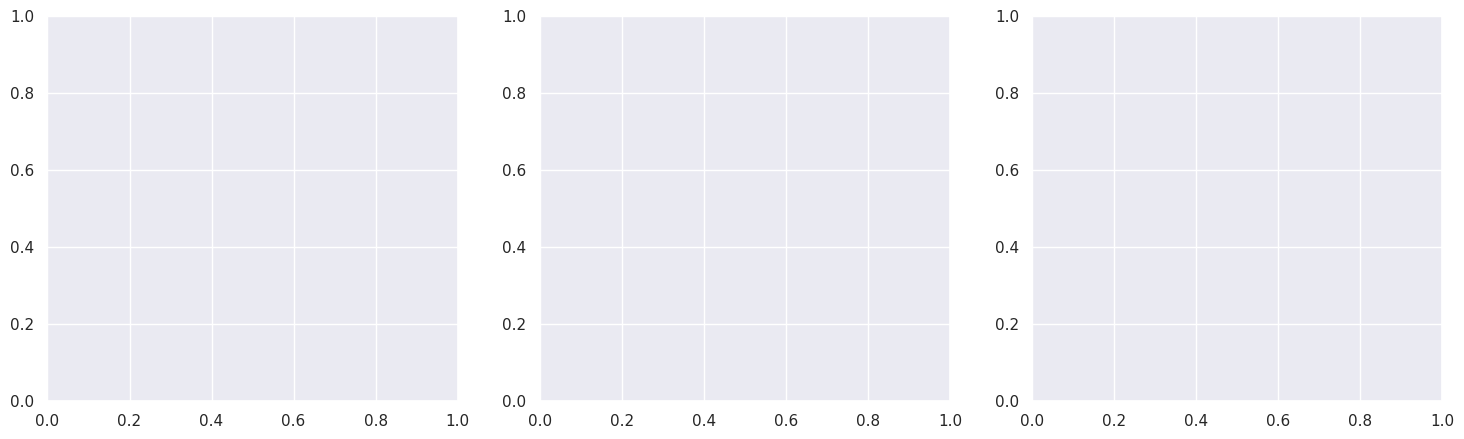

In [9]:
# FIXME
# Probar distintas configuraciones de Perplejidad
configuraciones = [5, 30, 50]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, perp in enumerate(configuraciones):
    tsne = TSNE(n_components=2, perplexity=perp, learning_rate=200, random_state=42, n_iter=1000)
    X_tsne = tsne.fit_transform(X_wine_scaled)

    sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y_wine, palette='Set1', ax=axes[idx], s=70, edgecolor='black')
    axes[idx].set_title(f't-SNE con Perplexity = {perp}', fontsize=12)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle("Impacto de la Perplejidad en la Topología de Vecindades de t-SNE", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n--- ANÁLISIS DE HIPERPARÁMETROS EN t-SNE ---")
print("1. Perplejidad muy baja (e.g., 5): El algoritmo se enfoca excesivamente en vecindades locales cortas, ")
print("   fragmentando artificialmente las clases en micro-grupos dispersos.")
print("2. Perplejidad intermedia (e.g., 30): Es la configuración óptima para este dataset, logrando agrupar ")
print("   las tres clases de vinos en islas o clústeres perfectamente definidos y aislados entre sí.")
print("3. Estructuras no lineales: t-SNE manifiesta agrupaciones más limpias y con fronteras de separación ")
print("   más marcadas que PCA debido a su capacidad intrínseca de mapeo probabilístico no lineal.")



### 3. **Comparación entre PCA y t-SNE**

* Contrastar las visualizaciones y discutir las **ventajas y limitaciones** de cada técnica:

  * PCA como método **lineal** para interpretar varianza y relaciones globales.
  * t-SNE como método **no lineal** que preserva relaciones locales y vecindades.
* Evaluar en qué escenarios prácticos sería más recomendable usar PCA (interpretabilidad, reducción previa para modelos) o t-SNE (exploración y visualización de clústeres).
* Reflexionar sobre la **importancia de la reducción de dimensionalidad** en datasets de alta dimensión como Wine, destacando su utilidad para:

  * Visualizar patrones ocultos en los datos.
  * Reducir complejidad y ruido antes de aplicar algoritmos de aprendizaje automático.
  * Facilitar la interpretación y comunicación de resultados.



Síntesis Comparativa: PCA vs t-SNE y Reflexión sobre la Alta Dimensión
1. Contraste de Técnicas
PCA (Enfoque Lineal Global): Busca maximizar la varianza global proyectando los puntos en nuevas direcciones ortogonales. Mantiene la interpretabilidad matemática de los datos a través de los loadings, permitiéndonos saber exactamente qué combinación de componentes químicos origina cada eje. Sin embargo, no separa las clases de forma tan tajante si las fronteras son curvas o complejas.

t-SNE (Enfoque No Lineal Local): Preserva distancias relativas o vecindades de corto alcance, atrayendo puntos similares y repeliendo puntos disímiles de manera probabilística. Es excelente para graficar visualmente clústeres puros, pero se pierden las distancias globales reales y no se dispone de una ecuación directa de transformación (no es almacenable ni interpretable por variables originales).

2. Escenarios Prácticos de Recomendación
Se recomienda usar PCA cuando el fin sea la reducción de ruido o la compresión de dimensiones previa a alimentar a otro modelo predictivo (como una Regresión o Clasificador lineal), y cuando la velocidad computacional o la explicación de la influencia de cada variable sea un factor crítico.

Se recomienda usar t-SNE estrictamente con fines exploratorios, de inspección visual de datos y validación cualitativa de si existen agrupaciones naturales u ocultas en conjuntos complejos de variables.

3. Importancia de la Reducción de Dimensionalidad en Datasets High-Dimensional
Mitigación de la "Maldición de la Dimensionalidad": A medida que aumentan las variables, el espacio se vuelve sumamente disperso y las distancias euclidianas tradicionales tienden a igualarse entre todas las muestras, afectando el desempeño de los modelos.

Eliminación de Redundancia: En datasets reales muchas variables están altamente correlacionadas. Reducir dimensiones extrae la señal real disolviendo el ruido informático.

Viabilidad Humana: Permite mapear sistemas incomprensibles de 13, 100 o miles de dimensiones directamente en planos 2D o 3D legibles para la toma de decisiones estratégicas.